In [1]:
# Necessary libraries and useful parameters
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.colorbar as cb

import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'lines.linewidth': 2.5, 'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

In [2]:
colors = ["#00274D", "#1B4F72", "#CFA6A6", "#CD5C5C", "#8B3A3A", "#641010"]
blue_red_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_map", colors)

red_colors = ["#F6CCCC", "#CD5C5C", "#641010"]
red_cmap = mcolors.LinearSegmentedColormap.from_list("custom_reds", red_colors)

In [3]:
# A 2D contour map of C
def contour_plot(Z, R, C, cmap=blue_red_cmap, cbar_label=r'$c/c_{\mathrm{max}}$'):
    contour = plt.contourf(Z, R, C, levels=200, cmap=cmap, vmax=1)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    plt.show()

In [4]:
# Model constants
R = 0.1   # tube radius [m]
L = 1   # tube length [m]
T = 100 # Characteristic time

# Scaled Langmuir adsorption constant
kA = 1

domain = ((0, 1), (0, 1), (0, 1))
M, K = 200, 100
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

In [5]:
# Scaled block matrix coefficients
def matrix_coeffs(params):
    E, U, D = params

    delta = ht/h**2 * D
    gamma =  ht/h**2 * D * (R/L)**2
    xi = ht/h * D*(E-1)/r
    vartheta = ht/h * U*(1-r**2)
    omega = xi + vartheta + 2*(gamma + delta) + 1

    return delta, gamma, xi, vartheta, omega

In [6]:
def coeff_matrix(M:int, coeffs) -> sp.csr_matrix:
    '''
    Create the block tridiagonal matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M: number of grid points
    '''
    Z = M*(M-1)
    delta, gamma, xi, vartheta, omega = coeffs

    ll = np.repeat(delta + xi[1:-1], M)      # Lowest diag
    l = np.repeat(gamma + vartheta[1:-1], M) # Next lowest diag
    d = np.repeat(omega[1:-1], M)            # Main diag 
    u = np.full(Z, gamma)                    # Next highest diag
    uu = np.full(Z, delta)                   # Highest diag
    
    l[M-1::M], u[M-1::M] = 0, 0 # Every M'th element is zero in l and d
    
    A = sp.diags([ll, l, -d, u, uu], [-M, -1, 0, 1, M], (Z, Z), format='csr')

    return A

In [7]:
def boundary_vector(grid:tuple, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int, coeffs, params) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      Ck: the previous concentration matrix
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2, g3 = BC
  delta, gamma, xi, vartheta, omega = coeffs
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M))
  G[::-1, 0] += (gamma+vartheta[1:-1]) * g1(r[1:-1], t[k+1]) # Left contribution
  G[-1, :] += (delta+xi[1]) * g2(z[1:], t[k+1])              # Bottom contribution
  G[0, :] += delta * g3(qk[1:], Ck[-2, 1:], params)                   # Top contribution

  return G[::-1].ravel() # return G as a vector

In [8]:
def concentration_scheme(grid:tuple, A:np.ndarray, g:np.ndarray, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int, params) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           A: the coefficient matrix
           k: the previous iteration step
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2, g3 = BC
   
    C = np.zeros((M+1, M+1))
    C[::-1, 0] = g1(r, t[k+1]) # Left boundary
    C[-1, :] = g2(z, t[k+1])   # Bottom boundary  
    C[0, 1:] = g3(qk[1:], Ck[-2, 1:], params) # Top boundary

    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:][::-1].ravel()))
    C[1:-1, 1:] = np.reshape(C_interior, (M-1, M))
   
    return C

In [9]:
def RK4(f, q, C):
    ''' 
    Solve a set of ODE's using the RK4-method.
    Input:
             f: the right hand side of the differential equations. Here: The Langmuir model
             q: initial values
        params: parameters needed by f. Here: cwall
    Output:
             q: numerical solutions
    '''
    k1 = f(q, C)
    k2 = f(q+ht*k1/2, C)
    k3 = f(q+ht*k2/2, C)
    k4 = f(q+ht*k3, C)
    
    return q + h/6*(k1 + 2*(k2 + k3) + k4)

In [10]:
# Initial condition
def f(z, r):                   
    return np.zeros_like(ZZ)   
                                                         
# Boundary conditions
def i(r, t): # inlet
    return 1-r**2  

def e(z, t): # electric
    return 0

def langmuir(q, C, kA=kA): # RHS of langmuir model to be solved with RK4
    return kA*C*(1-q)
def d(qk, C, params): # deposition (discretized)
    E, U, D = params
    return C / (1 - h*((D*E)/r[-1] - kA/D *(1-qk)))

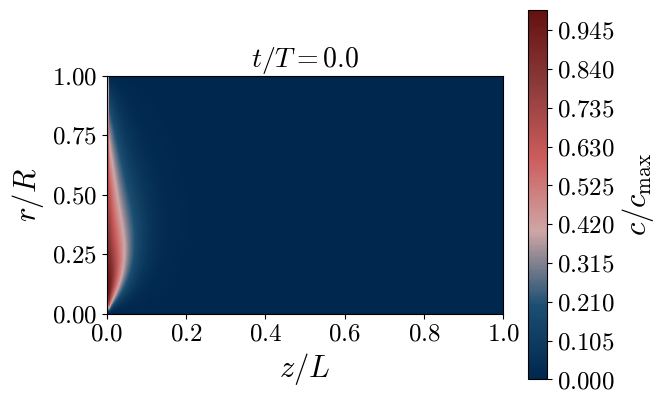

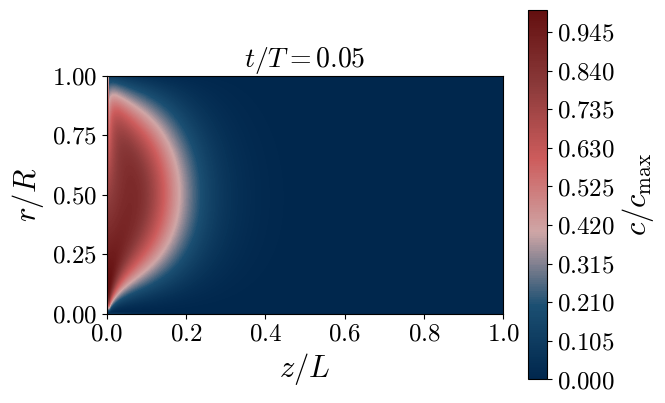

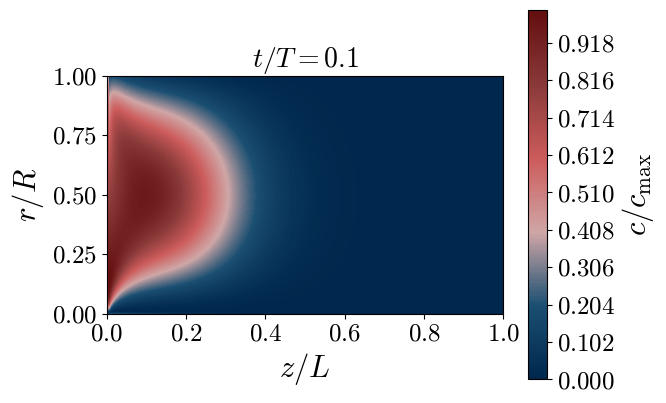

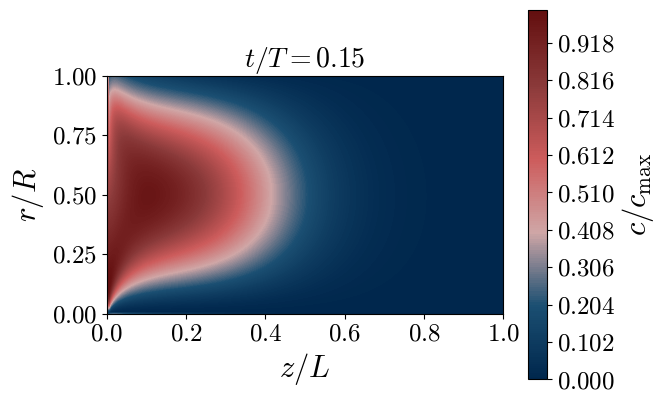

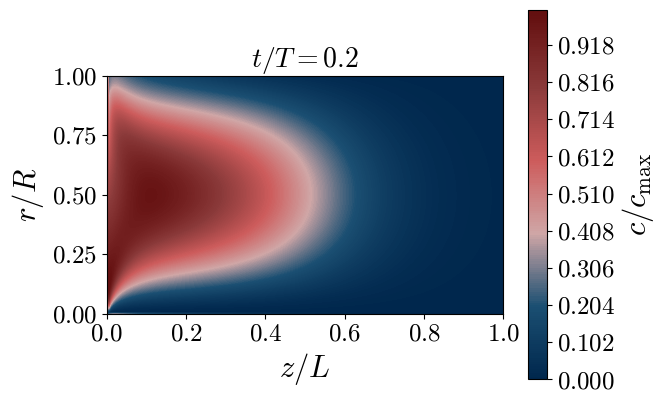

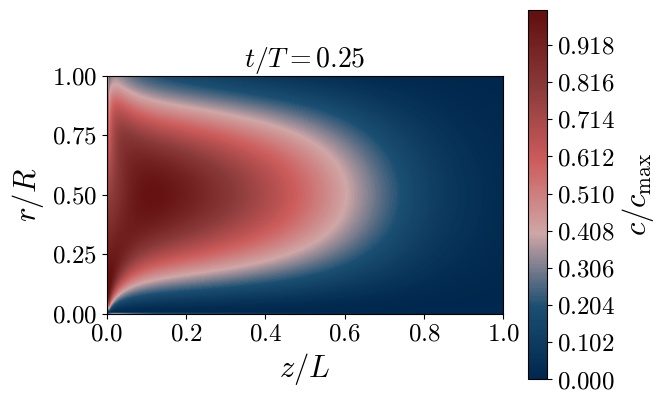

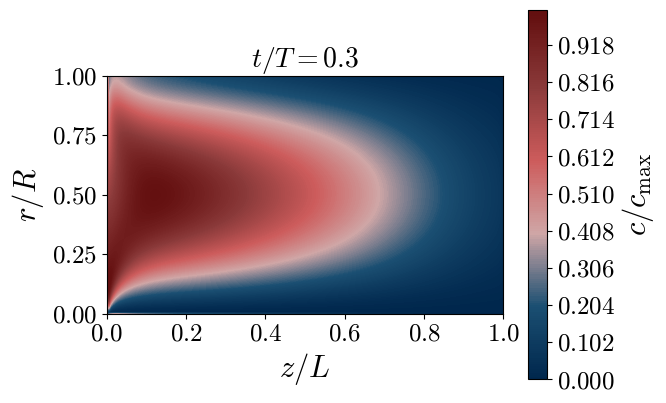

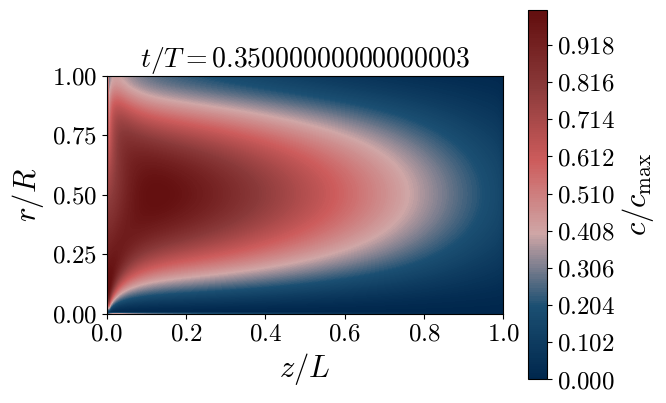

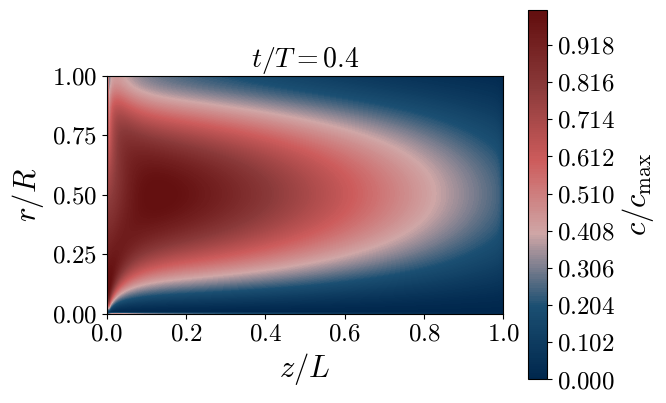

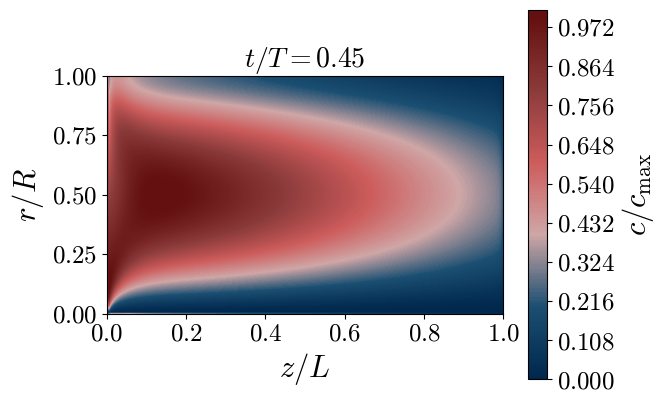

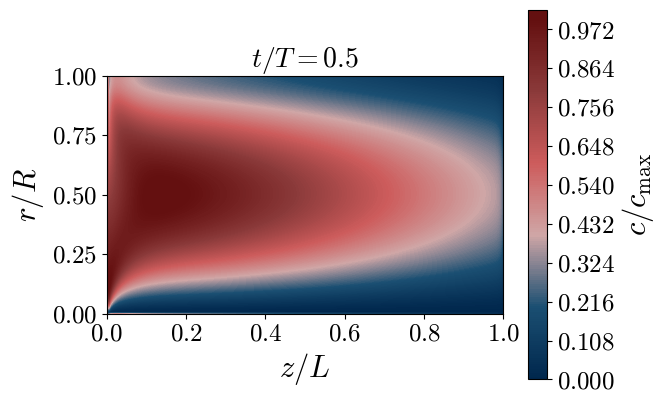

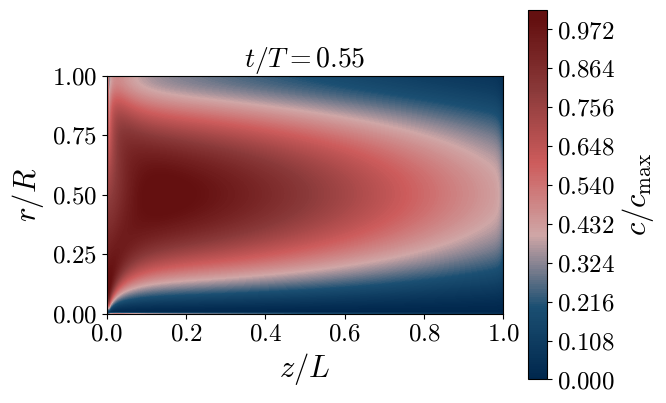

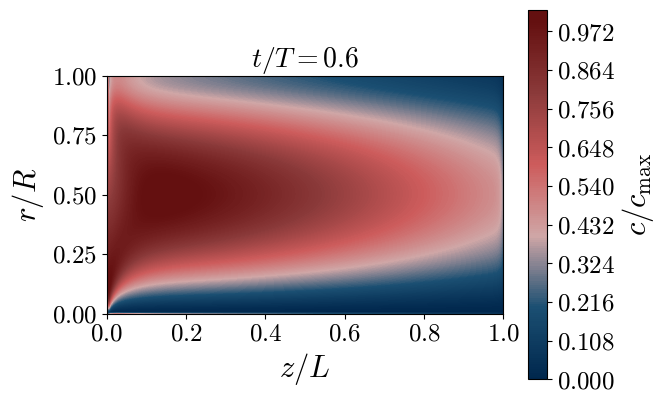

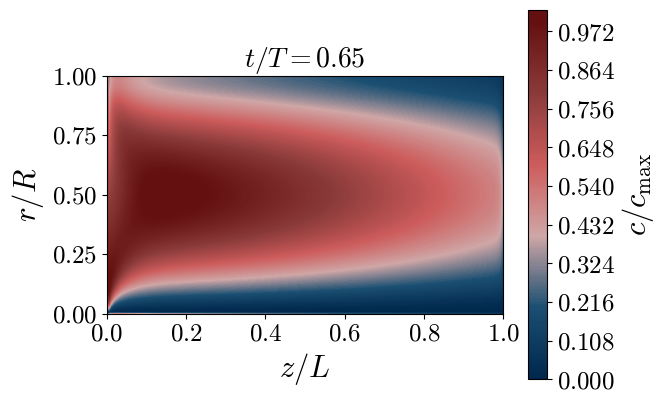

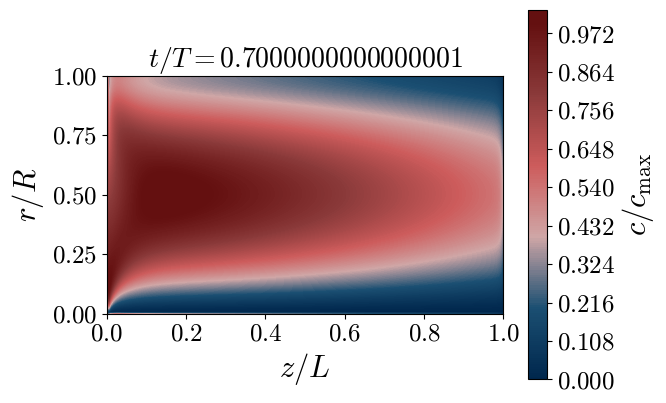

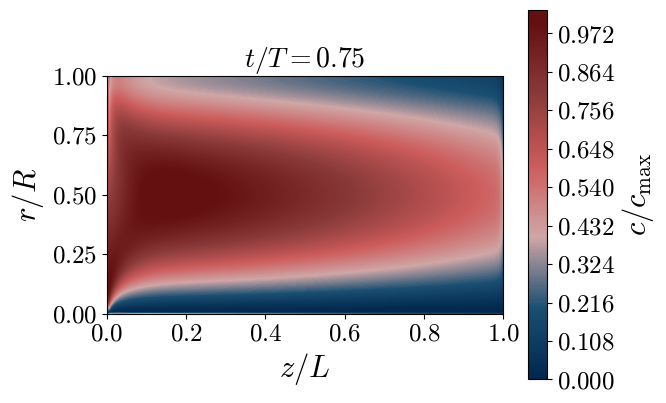

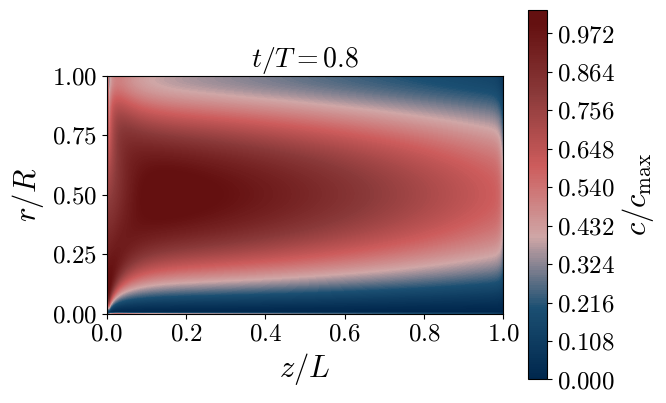

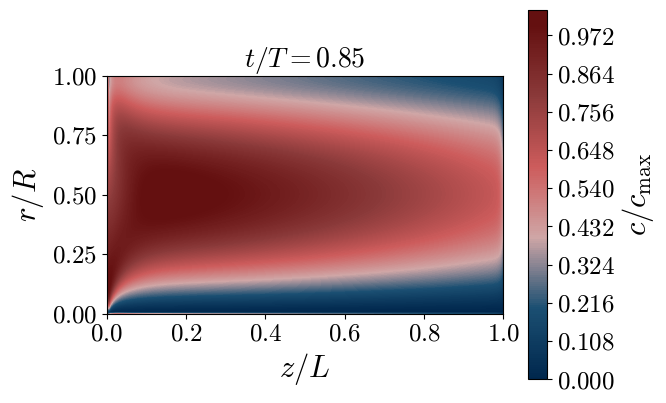

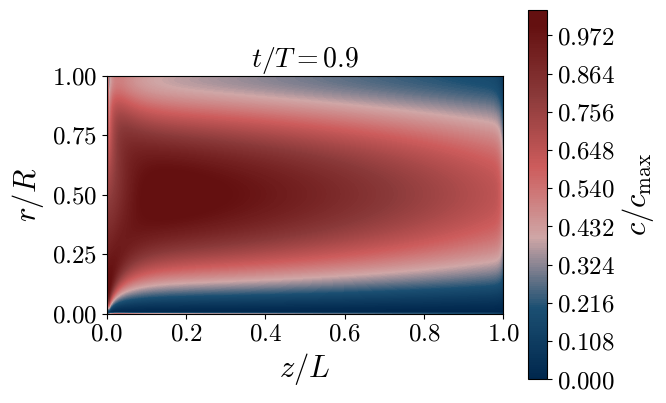

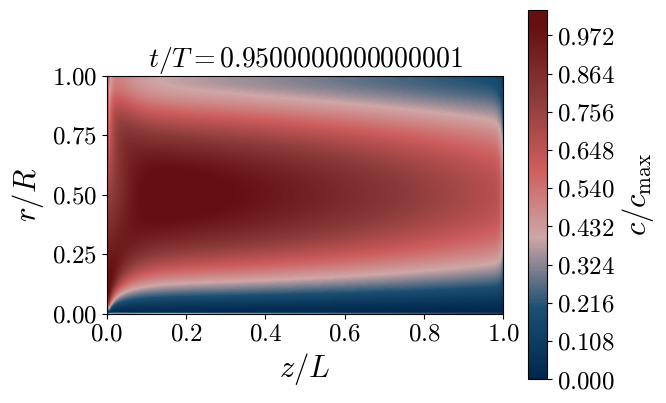

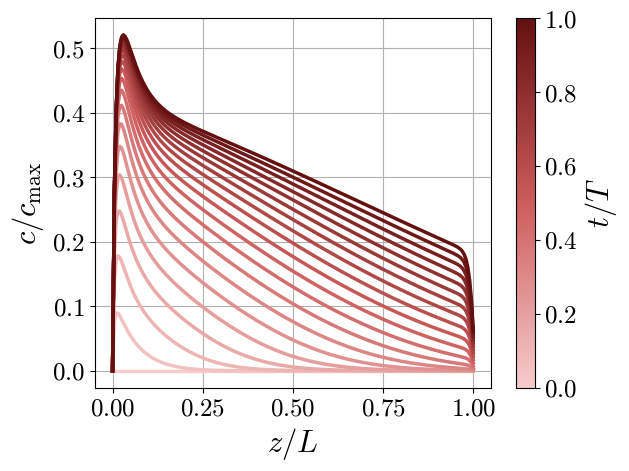

In [11]:
# EXAMPLE 1 --- CONSTANT COEFFICIENTS - TIME EVOLUTION - DEPOSITION PROFILE #
# Scaled constants
E, U, D = 3, 4, 1
params = [E, U, D]

delta, gamma, xi, vartheta, omega = matrix_coeffs(params)
coeffs = [delta, gamma, xi, vartheta, omega]

BC = (i, e, d)
A = coeff_matrix(M, coeffs)
C0 = f(ZZ, RR)      # Initial concentration matrix
q0 = np.zeros(M+1)  # Initial wall surface coverage
Cwall = np.zeros((K, M+1)) # Store the wall concentrations after every time step

Ck = C0
qk = q0
for k, time in enumerate(t[:-1]):
    g = boundary_vector(grid, k, qk, Ck, BC, M, coeffs, params)
    C = concentration_scheme(grid, A, g, k, qk, Ck, BC, M, params)
    Cwall[k] = C[0]

    q = RK4(langmuir, qk, C[-1, :])

    if k%5 == 0:
        plt.figure()
        plt.title(f'$t/T = {time}$')
        contour_plot(ZZ, RR, C)

    Ck = C
    qk = q

# Plot wall concentration evolution
plt.figure()
for i, k in enumerate(range(0, K, 5)):
    color = red_cmap(i / ((K-1) // 5))
    plt.plot(z, Cwall[k], color=color)
    
plt.xlabel('$z/L$')
plt.ylabel(r'$c/c_{\mathrm{max}}$')
plt.grid(True)

sm = plt.cm.ScalarMappable(cmap=red_cmap, norm=plt.Normalize(vmin=t[0], vmax=t[-1]))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$t/T$')

plt.show()